# Lab 3: Edge and line detection

In [1]:
import cv2
import numpy as np
import os
import math
from matplotlib import pyplot as plt
import ipywidgets as widgets

dataDir = '../images' # Change this, according to your images' directory path

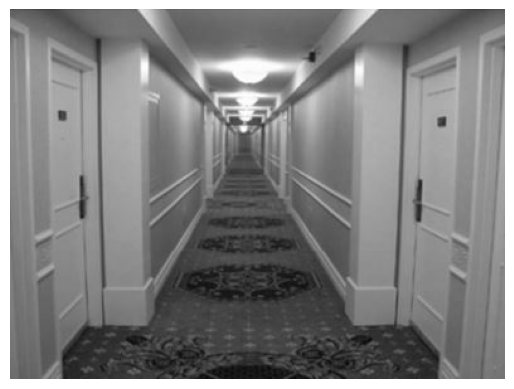

In [2]:
# Open image
img = cv2.imread(os.path.join(dataDir, 'corridor_01.jpg')) # Change this, according to your image's path

# Convert to grayscale
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img, cmap="gray", vmin=0, vmax=255)
_ = plt.axis("off")

### 1. Sobel Filter

Detecting edges using the [Sobel Filter](https://docs.opencv.org/master/d4/d86/group__imgproc__filter.html#gacea54f142e81b6758cb6f375ce782c8d)

(294, 393)


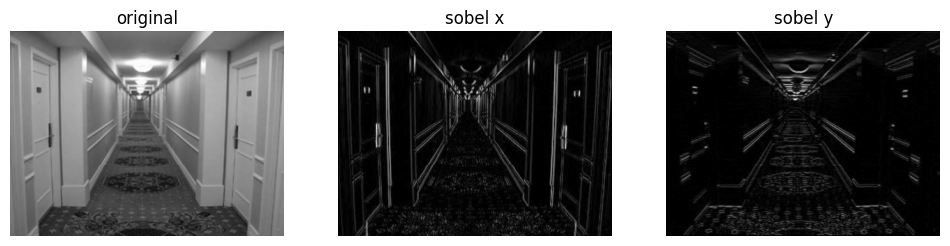

In [ ]:
# Calculate the first derivatives of the image in x and y
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

# Normalize the result 
sobel_x = (np.abs(sobel_x) / np.abs(sobel_x).max()) * 255.
sobel_y = (np.abs(sobel_y) / np.abs(sobel_y).max()) * 255.

# Show the images
f, axarr = plt.subplots(1, 3, figsize=(12, 4))

axarr[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axarr[0].set_title("original")
axarr[0].axis("off")

axarr[1].imshow(sobel_x, cmap="gray", vmin=0, vmax=255)
axarr[1].set_title("sobel x")
axarr[1].axis("off")

axarr[2].imshow(sobel_y, cmap="gray", vmin=0, vmax=255)
axarr[2].set_title("sobel y")
_ = axarr[2].axis("off")

Exercise 1.1: Calculate the magnitude of the gradient by combining the previously calculated partial derivatives (sobel_x and sobel_y) and show the resulting image.

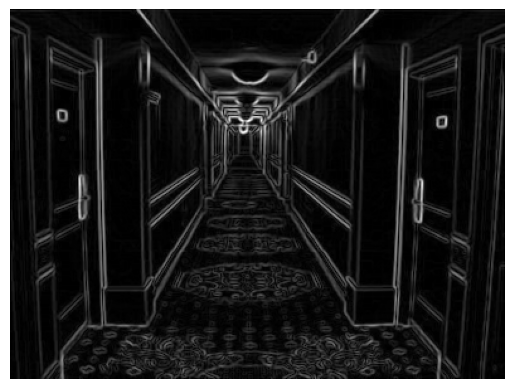

In [27]:
magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

magnitude = (magnitude / magnitude.max()) * 255.

axarr = plt.imshow(magnitude, cmap="gray", vmin=0, vmax=255)
_ = plt.axis("off")

Exercise 1.2: Threshold the gradient image using an interactive slider (e.g., [opencv trackbar](https://docs.opencv.org/4.x/da/d6a/tutorial_trackbar.html) or [pywidgets interact](https://ipywidgets.readthedocs.io/en/8.1.2/examples/Using%20Interact.html)).

In [38]:
def f(threshold):
    # Show the images
    f, axarr = plt.subplots(1, 2, figsize=(12, 4))

    axarr[0].imshow(img, cmap="gray", vmin=0, vmax=255)
    axarr[0].set_title("Original")
    axarr[0].axis("off")

    _, magnitude_thresholded = cv2.threshold(magnitude, threshold, 255, cv2.THRESH_BINARY)

    axarr[1].imshow(magnitude_thresholded, cmap="gray", vmin=0, vmax=255)
    axarr[1].set_title("Gradient Image")
    axarr[1].axis("off")

    return

widgets.interact(f, threshold=widgets.IntSlider(min=0, max=255, step=1, value=10))

interactive(children=(IntSlider(value=10, description='threshold', max=255), Output()), _dom_classes=('widget-…

<function __main__.f(threshold)>

Exercise 1.3: Test the effect of applying Gaussian blur filters of different sizes before applying the Sobel filter.

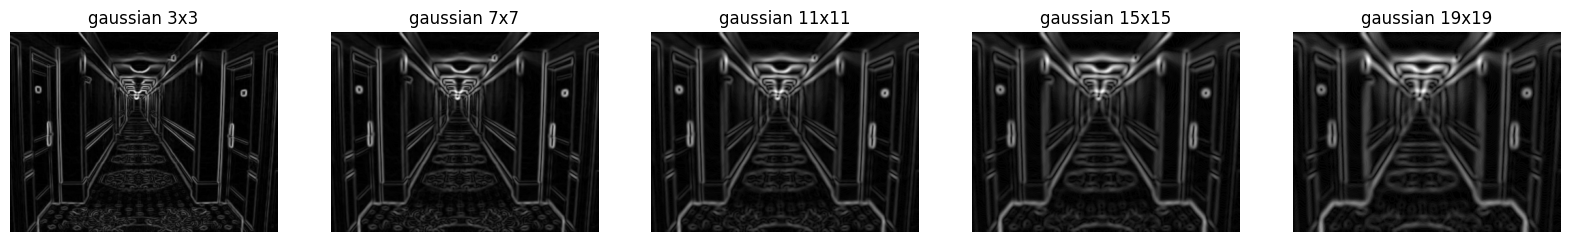

In [40]:

def gaussian_sobel(sigma):
    images = []

    for i in range(3,22,4):
        gaussian = cv2.GaussianBlur(img, (i,i), sigma)

        sobel_x = cv2.Sobel(gaussian, cv2.CV_64F, 1, 0, ksize=3)
        sobel_y = cv2.Sobel(gaussian, cv2.CV_64F, 0, 1, ksize=3)

        final_img = np.sqrt(sobel_x**2 + sobel_y**2)
        final_img = (final_img / final_img.max()) * 255.

        images.append(final_img)

    f, axarr = plt.subplots(1 , len(images),figsize=(4*len(images),4))

    for i,new_img in enumerate(images):
        axarr[i].imshow(new_img, cmap="gray", vmin=0,vmax=255)
        axarr[i].set_title(f"gaussian {3 + i * 4}x{3 + i * 4}")
        axarr[i].axis("off")


gaussian_sobel(0)


Exercise 1.4: Experiment with different kernel sizes in the sobel filter

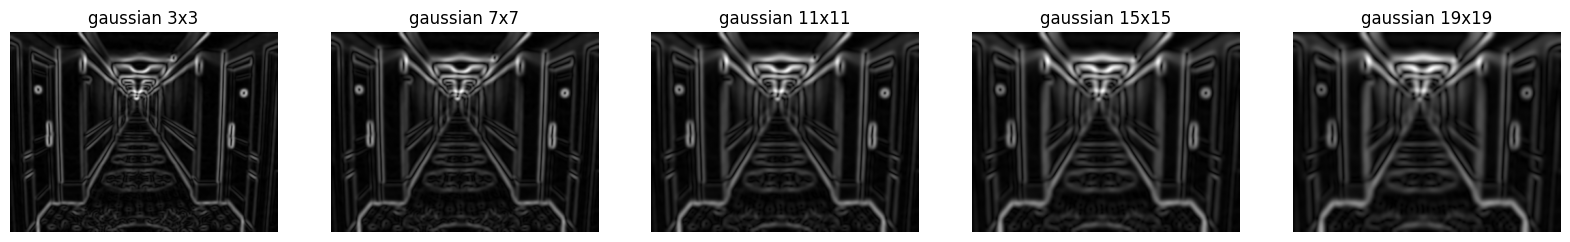

In [46]:
def gaussian_sobel(sigma):
    images = []

    kernel_size = 12

    for i in range(3,22,4):
        gaussian = cv2.GaussianBlur(img, (i,i), sigma)

        sobel_x = cv2.Sobel(gaussian, cv2.CV_64F, 1, 0, ksize=kernel_size + i)
        sobel_y = cv2.Sobel(gaussian, cv2.CV_64F, 0, 1, ksize=kernel_size + i)

        final_img = np.sqrt(sobel_x**2 + sobel_y**2)
        final_img = (final_img / final_img.max()) * 255.
        images.append(final_img)

    f, axarr = plt.subplots(1 , len(images),figsize=(4*len(images),4))

    for i,new_img in enumerate(images):
        axarr[i].imshow(new_img, cmap="gray", vmin=0,vmax=255)
        axarr[i].set_title(f"gaussian {3 + i * 4}x{3 + i * 4}")
        axarr[i].axis("off")


gaussian_sobel(0)


### 2. Laplacian of Gaussian (LoG) and Difference of Gaussians (DoG)

Edge detection using the Laplacian filter

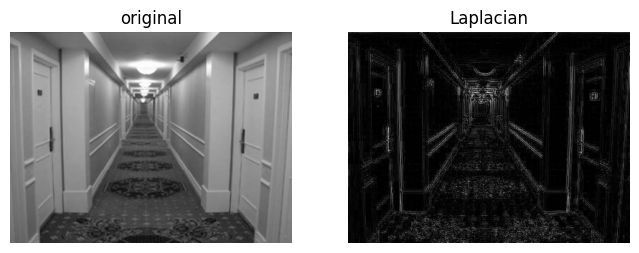

In [47]:
# Open image
img = cv2.imread(os.path.join(dataDir, 'corridor_01.jpg')) # Change this, according to your image's path

# Convert to grayscale
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Laplacian
laplacian = cv2.Laplacian(img, cv2.CV_64F, ksize=3)

# Normalize result
laplacian = (np.abs(laplacian) / np.abs(laplacian).max()) * 255.

## Show the image
f, axarr = plt.subplots(1, 2, figsize=(8, 4))

axarr[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axarr[0].set_title("original")
axarr[0].axis("off")

axarr[1].imshow(laplacian, cmap="gray", vmin=0, vmax=255)
axarr[1].set_title("Laplacian")
_ = axarr[1].axis("off")

Exercise 2.1: Calculate the Laplacian of Gaussian by applying a Gaussian filter before applying the Laplacian filter

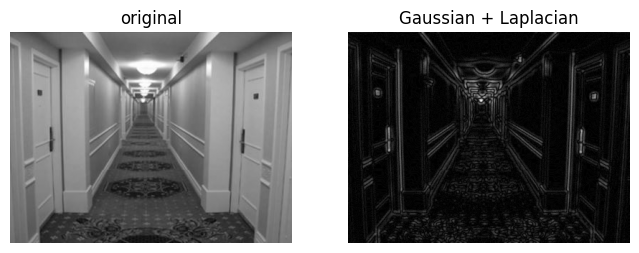

In [54]:
# Open image
img = cv2.imread(os.path.join(dataDir, 'corridor_01.jpg')) # Change this, according to your image's path

# Convert to grayscale
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian
gaussian = cv2.GaussianBlur(img,(7,7),0)

# Apply Laplacian
laplacian = cv2.Laplacian(gaussian, cv2.CV_64F, ksize=3)

# Normalize result
laplacian = (np.abs(laplacian) / np.abs(laplacian).max()) * 255.

## Show the image
f, axarr = plt.subplots(1, 2, figsize=(8, 4))

axarr[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axarr[0].set_title("original")
axarr[0].axis("off")

axarr[1].imshow(laplacian, cmap="gray", vmin=0, vmax=255)
axarr[1].set_title("Gaussian + Laplacian")
_ = axarr[1].axis("off")

Exercise 2.2: Implement edge detection through Difference of Gaussians

[[254 254 253 ... 253 253 253]
 [255 255 255 ... 253 254 254]
 [255 255 255 ... 255   0   0]
 ...
 [255 255   1 ... 255   0   0]
 [255   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]]


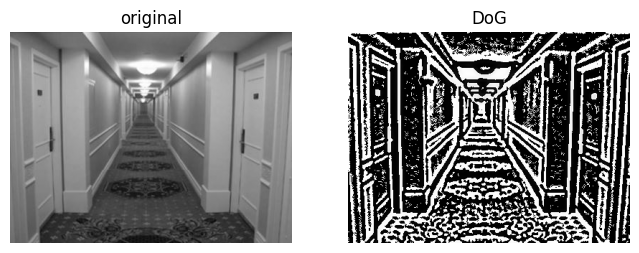

In [64]:
# Open image
img = cv2.imread(os.path.join(dataDir, 'corridor_01.jpg')) # Change this, according to your image's path

# Convert to grayscale
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian
gaussian_1 = cv2.GaussianBlur(img,(7,7),0)

gaussian_2 = cv2.GaussianBlur(img,(13,13),0)

final_img = gaussian_1 - gaussian_2

print(final_img)
## Show the image
f, axarr = plt.subplots(1, 2, figsize=(8, 4))

axarr[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axarr[0].set_title("original")
axarr[0].axis("off")

axarr[1].imshow(final_img, cmap="gray", vmin=0, vmax=255)
axarr[1].set_title("DoG")
_ = axarr[1].axis("off")

### 3. Canny Edge Filter

Detect edges using the [Canny Filter](https://docs.opencv.org/master/dd/d1a/group__imgproc__feature.html#ga04723e007ed888ddf11d9ba04e2232de)

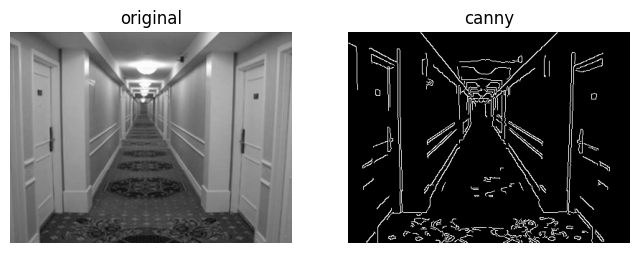

In [65]:
# Apply a Canny Filter
img_canny = cv2.Canny(img, 100, 200)

# Show image
f, axarr = plt.subplots(1, 2, figsize=(8, 4))

axarr[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axarr[0].set_title("original")
axarr[0].axis("off")

axarr[1].imshow(img_canny, cmap="gray", vmin=0, vmax=255)
axarr[1].set_title("canny")
_ = axarr[1].axis("off")

Exercise 3.1: Implement two track bars to alter the low and high threshold values of the Canny filter

In [ ]:
def trackbar_values(low,high):
    # Apply a Canny Filter
    img_canny = cv2.Canny(img, low, high)

    # Show image
    f, axarr = plt.subplots(1, 2, figsize=(8, 4))

    axarr[0].imshow(img, cmap="gray", vmin=0, vmax=255)
    axarr[0].set_title("original")
    axarr[0].axis("off")

    axarr[1].imshow(img_canny, cmap="gray", vmin=0, vmax=255)
    axarr[1].set_title("canny")
    _ = axarr[1].axis("off")

widgets.interact(trackbar_values, low=widgets.IntSlider(min=0, max=255, step=1, value=100),high=widgets.IntSlider(min=0, max=255, step=1, value=200) )


interactive(children=(IntSlider(value=100, description='low', max=255), IntSlider(value=200, description='high…

<function __main__.trackbar_values(low, high)>

Exercise 3.2: Compare the results of applying the following two filters to the same image:
 - Sobel filter, with threshold t, after smoothing the image with a Gaussian blur filter with size s;
 - Canny filter, with "low threshold" = "high threshold" = t and "aperture" = s, using the same t and s values. Try also with a "low threshold" different from the "high threshold".

In [77]:
# Open image
img = cv2.imread(os.path.join(dataDir, 'corridor_01.jpg')) # Change this, according to your image's path

# Convert to grayscale
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# First Image
filter_size = 5

gaussian_blur = cv2.GaussianBlur(img, (filter_size, filter_size), 0)

# Calculate the first derivatives of the image in x and y
sobel_x = cv2.Sobel(gaussian_blur, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gaussian_blur, cv2.CV_64F, 0, 1, ksize=3)

# Normalize the result 
sobel_x = (np.abs(sobel_x) / np.abs(sobel_x).max()) * 255.
sobel_y = (np.abs(sobel_y) / np.abs(sobel_y).max()) * 255.

sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

sobel_magnitude = (sobel_magnitude / sobel_magnitude.max()) * 255.

# Second Image



def track(threshold, threshold_max):
    _, sobel_tresholded = cv2.threshold(sobel_magnitude,threshold,255,cv2.THRESH_BINARY)
    f, axarr = plt.subplots(1, 2, figsize=(8, 4))
    img_canny = cv2.Canny(img, threshold, threshold_max, apertureSize=filter_size)

    axarr[0].imshow(sobel_tresholded, cmap="gray", vmin=0, vmax=255)
    axarr[0].set_title("Sobel Filter")
    axarr[0].axis("off")


    axarr[1].imshow(img_canny, cmap="gray", vmin=0, vmax=255)
    axarr[1].set_title("Canny")
    axarr[1].axis("off")

widgets.interact(track, threshold=widgets.IntSlider(min=0, max=255, step=1, value=100), threshold_max=widgets.IntSlider(min=0, max=255, step=1, value=100) )



interactive(children=(IntSlider(value=100, description='threshold', max=255), IntSlider(value=100, description…

<function __main__.track(threshold, threshold_max)>

### Extra: Hough Line Transform

Example of [Standard Hough Lines Transform](https://docs.opencv.org/3.4/dd/d1a/group__imgproc__feature.html#ga46b4e588934f6c8dfd509cc6e0e4545a)

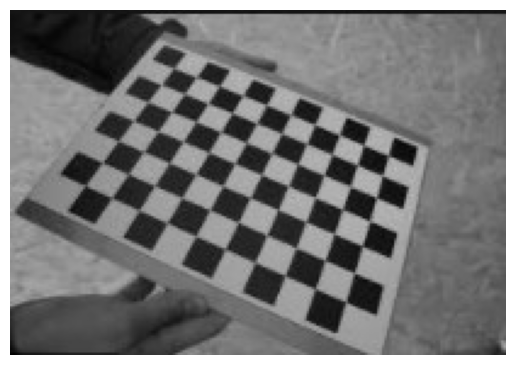

In [14]:
# Opening an image
img2 = cv2.imread(os.path.join(dataDir, 'chessboard_02.jpg'))

# Convert to grayscale
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Display image
plt.imshow(img2, cmap="gray", vmin=0, vmax=255)
_ = plt.axis("off")

Step 1: Detect the edges of the input image using a Canny Filter

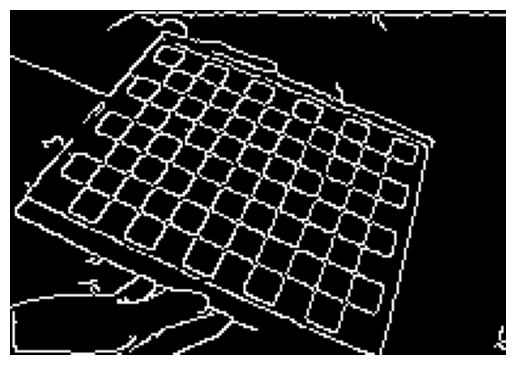

In [15]:
# Apply Canny filter
img2_canny = cv2.Canny(img2, 50, 200)

# Create BGR copy of image
img2_copy = cv2.cvtColor(img2_canny, cv2.COLOR_GRAY2BGR)

# Display image
plt.imshow(img2_canny, cmap="gray", vmin=0, vmax=255)
_ = plt.axis("off")

Step 2: Apply Hough Transform

In [16]:
num_votes = 60

lines = cv2.HoughLines(img2_canny, 1, np.pi / 180, num_votes, None, 0, 0)

Step 3: Draw the lines

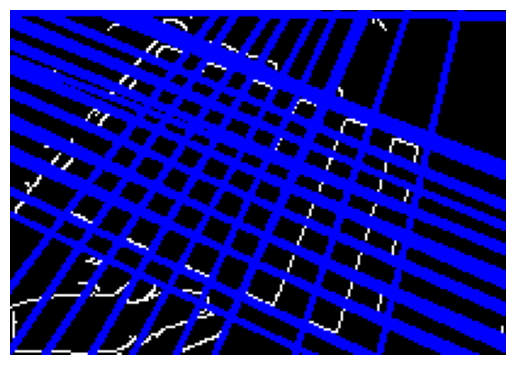

In [17]:
if lines is not None:
    for i in range(0, len(lines)):
        rho = lines[i][0][0]
        theta = lines[i][0][1]
        a = math.cos(theta)
        b = math.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        # Draw the line
        cv2.line(img2_copy, pt1, pt2, (255, 0, 0), 2)

## Show the image
plt.imshow(cv2.cvtColor(img2_copy, cv2.COLOR_BGR2RGB))
_ = plt.axis("off")
